# 05 – Handmerkmale extrahieren und Feature-Konfiguration festlegen

MediaPipe Hand Landmarker wird zur Erkennung von bis zu zwei Händen verwendet. Aus den Landmarkpositionen werden 178 geometrische Merkmale aus normalisierten Koordinaten, Gelenkwinkeln, Distanzen und der relativen Lage beider Hände berechnet. Fehlende Hände werden nicht durch künstliche Merkmale ersetzt. Die Feature-Konfiguration wird ausschließlich anhand von Training und Validation festgelegt.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

here = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (here, *here.parents)
     if (p / "notebooks").is_dir() and (p / "data").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Projektordner mit notebooks/ und data/ fehlt.")
if not (PROJECT_ROOT / "src/tlfs23/data.py").is_file():
    raise FileNotFoundError("Den Ordner src/tlfs23 aus dem Paket ins Projekt kopieren.")

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from tlfs23 import data as d
from tlfs23 import features as f
from tlfs23.common import paths

P = paths(PROJECT_ROOT)
plan, split_info = d.load_split(PROJECT_ROOT)
train = plan.loc[plan["split"].eq("train")].copy()
development = plan.loc[plan["split"].isin(["train", "validation"])].copy()
TASK_PATH = f.model_path(PROJECT_ROOT)

print("Projekt:", PROJECT_ROOT)
print("Detektor:", TASK_PATH)
print("Geometrische Merkmale:", len(f.FEATURE_NAMES))


Projekt: /Users/sharu/Documents/DBU/tamil-finger-sign-mlops
Detektor: /Users/sharu/Documents/DBU/tamil-finger-sign-mlops/models/detector/hand_landmarker_v1.task
Geometrische Merkmale: 178


## 1. Split-Integrität prüfen

Der in Notebook 04 festgeschriebene Split wird geladen und auf eine mögliche Überschneidung der Bildgruppen zwischen Training, Validation und Test geprüft. Anschließend wird die Verteilung der Kategorien über die drei Splits kontrolliert.


In [2]:
group_column = next(
    (c for c in ["split_group_id", "group_id"] if c in plan.columns),
    None,
)

if group_column is not None:
    leaking_groups = (
        plan.groupby(group_column)["split"]
        .nunique()
        .gt(1)
        .sum()
    )

    if leaking_groups:
        raise ValueError(
            f"{leaking_groups} Bildgruppen liegen in mehreren Splits."
        )

    print("Gruppen über mehrere Splits:", leaking_groups)

display(
    pd.crosstab(
        plan["split"],
        plan["category"],
    )
)


Gruppen über mehrere Splits: 0


category,ayudha,background,mei,uyir,uyirmei
split,,,,,
test,50,100,900,600,10800
train,360,360,6480,4320,38880
validation,50,100,900,600,10800


## 2. Detektorkonfigurationen vergleichen

Für eine Trainingsstichprobe werden drei MediaPipe-Konfigurationen verglichen: Standard-Schwellen, niedrigere Schwellen und ein einzelner deterministischer Kontrast-/Helligkeits-Retry. Der größere Uyirmei-Anteil berücksichtigt die deutlich höhere Zahl unterschiedlicher Zeichen. Verglichen werden insbesondere vollständige Zwei-Hand-Erkennungen, unvollständige Detektionen, Background-Fälle und Laufzeit. [MediaPipe Hand Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python).


In [3]:
BASE_CONFIG = {
    "detection_threshold": 0.5,
    "presence_threshold": 0.5,
    "retry": False,
    "max_side": 768,
}

CONFIGS = {
    "standard": BASE_CONFIG,
    "sensitive": dict(
        BASE_CONFIG,
        detection_threshold=0.35,
        presence_threshold=0.35,
    ),
    "retry": dict(
        BASE_CONFIG,
        detection_threshold=0.35,
        presence_threshold=0.35,
        retry=True,
    ),
}

PILOT_PER_CATEGORY = {
    "uyir": 20,
    "mei": 20,
    "uyirmei": 60,
    "ayudha": 20,
    "background": 20,
}

pilot_parts = []

for category, group in train.sort_values("sha256").groupby("category", sort=True):
    n = PILOT_PER_CATEGORY.get(category, 20)
    diverse = group.drop_duplicates("character")
    selected = diverse.head(n)

    if len(selected) < n:
        remaining = group.loc[
            ~group.index.isin(selected.index)
        ].head(n - len(selected))
        selected = pd.concat([selected, remaining], axis=0)

    pilot_parts.append(selected)

pilot = pd.concat(pilot_parts, axis=0).reset_index(drop=True)
pilot_samples = f.samples(pilot, augment_train=False)

print("Pilotbilder insgesamt:", len(pilot_samples))

display(
    pilot.groupby("category")
    .agg(
        n_images=("relative_path", "size"),
        n_characters=("character", "nunique"),
    )
)

f.preflight(
    PROJECT_ROOT,
    BASE_CONFIG,
)


Pilotbilder insgesamt: 140


,n_images,n_characters
category,,
ayudha,20,1
background,20,1
mei,20,18
uyir,20,12
uyirmei,60,60


MediaPipe-Initialisierung im separaten Prozess erfolgreich.


In [4]:
pilot_results, tables = {}, []

for name, config in CONFIGS.items():
    rows, directory = f.run_extraction(
        PROJECT_ROOT,
        pilot_samples,
        config,
        name="pilot_" + name,
        chunk_size=64,
        timeout=180,
    )
    pilot_results[name] = (rows, directory)
    tables.append(
        f.detection_summary(rows).assign(configuration=name)
    )

comparison = pd.concat(tables, ignore_index=True)
comparison.to_csv(
    P["work"] / "05_detector_comparison.csv",
    index=False,
)

summary_rows = []

for name, (rows, _) in pilot_results.items():
    signs = rows[rows["category"] != "background"]
    background = rows[rows["category"] == "background"]

    summary_rows.append({
        "config": name,
        "sign_two_hand_rate": signs["status"].eq("ok").mean(),
        "sign_incomplete_rate": signs["status"].eq("incomplete_pair").mean(),
        "background_two_hand_rate": background["status"].eq("ok").mean(),
        "median_ms": rows["extract_ms"].median(),
    })

summary_table = pd.DataFrame(summary_rows).round(3)
display(summary_table)

SELECTED_CONFIG = "retry"


Cache: 64/140
Cache: 128/140
Cache: 140/140
Cache: 64/140
Cache: 128/140
Cache: 140/140
Cache: 64/140
Cache: 128/140
Cache: 140/140


,config,sign_two_hand_rate,sign_incomplete_rate,background_two_hand_rate,median_ms
0,standard,0.642,0.233,0.05,30.754
1,sensitive,0.667,0.225,0.05,30.300
2,retry,0.692,0.200,0.05,33.358


## 3. Landmark-Erkennung und Augmentierung visuell prüfen

Für die ausgewählte Retry-Konfiguration werden erfolgreiche und unvollständige Detektionen aus allen Kategorien betrachtet. Die visuelle Prüfung ergänzt die Detektionsraten, da eine Zwei-Hand-Erkennung allein noch keine plausiblen Landmarkpositionen garantiert.

Für Uyir- und Mei-Trainingsbilder wird zusätzlich eine leichte deterministische Augmentierung geprüft. Sie umfasst maximal sechs Grad Rotation sowie geringe Helligkeits- und Kontraständerungen. Spiegelung wird nicht verwendet; Validation und Test bleiben unverändert.


Bilder zur visuellen Prüfung: 19


**யா | uyirmei | original**  
Status: `ok`, Haende: 2, Retry: False

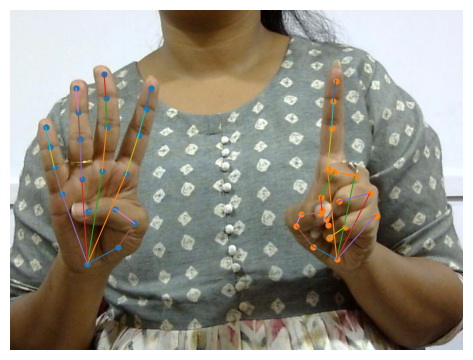

**மை | uyirmei | original**  
Status: `ok`, Haende: 2, Retry: False

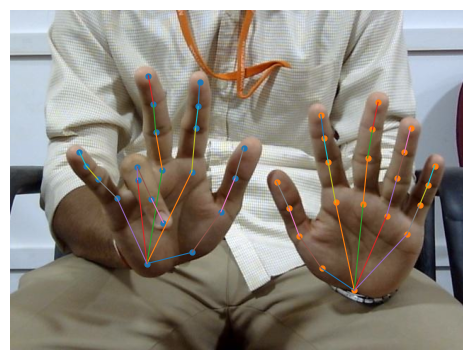

**ஃ | ayudha | original**  
Status: `ok`, Haende: 2, Retry: False

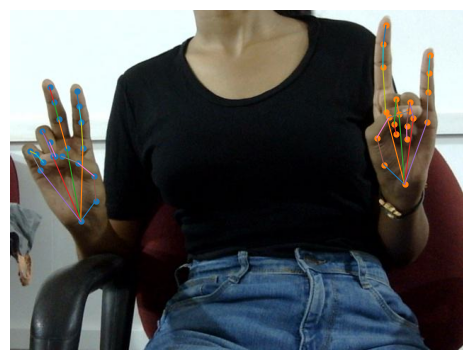

**ஏ | uyir | original**  
Status: `ok`, Haende: 2, Retry: False

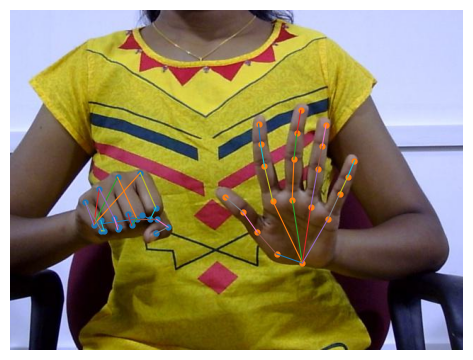

**த் | mei | original**  
Status: `ok`, Haende: 2, Retry: False

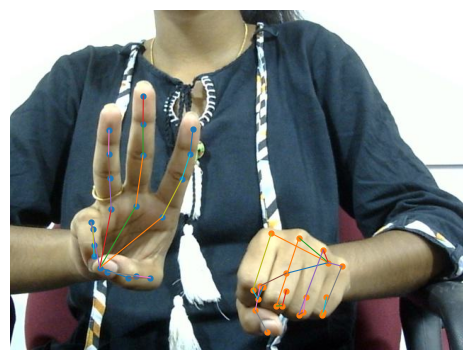

**ஓ | uyir | original**  
Status: `ok`, Haende: 2, Retry: False

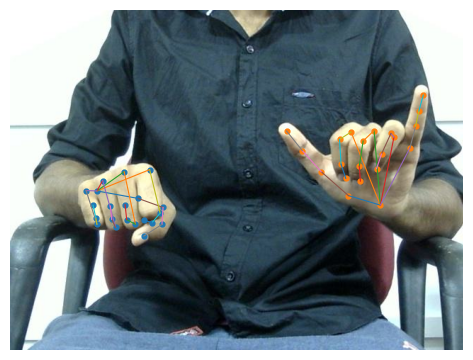

**ஃ | ayudha | original**  
Status: `ok`, Haende: 2, Retry: False

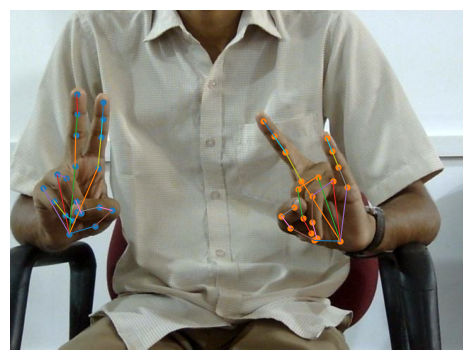

**வ் | mei | original**  
Status: `ok`, Haende: 2, Retry: False

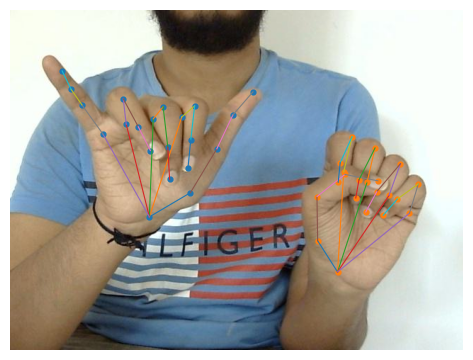

**__background__ | background | original**  
Status: `ok`, Haende: 2, Retry: False

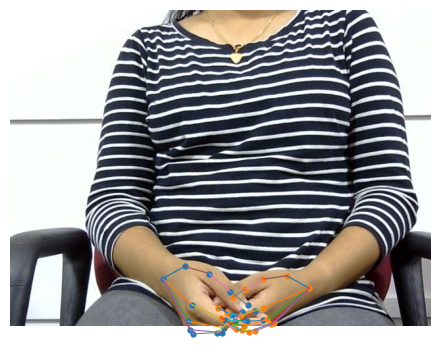

**ய் | mei | original**  
Status: `incomplete_pair`, Haende: 1, Retry: True

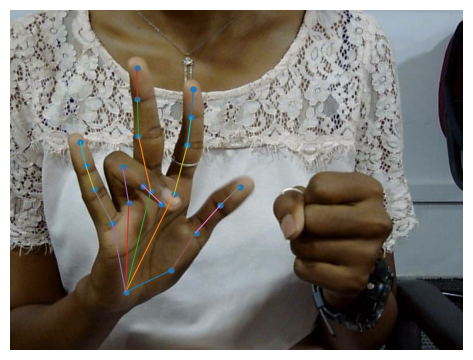

**கை | uyirmei | original**  
Status: `incomplete_pair`, Haende: 1, Retry: True

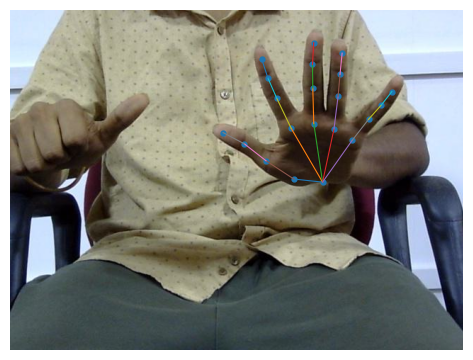

**ஃ | ayudha | original**  
Status: `incomplete_pair`, Haende: 1, Retry: True

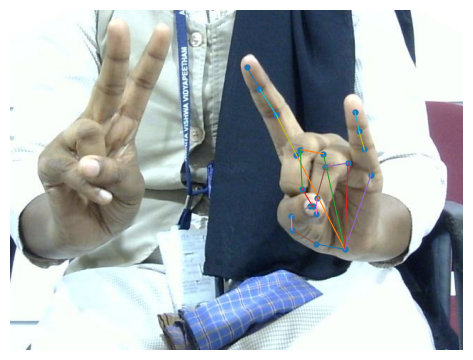

**ஃ | ayudha | original**  
Status: `incomplete_pair`, Haende: 1, Retry: True

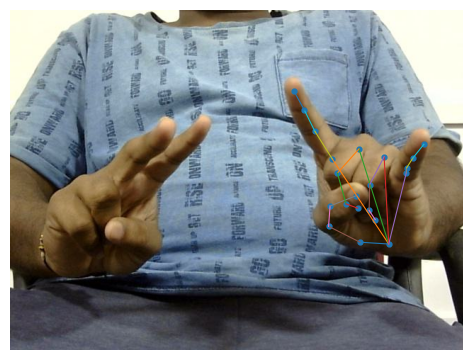

**__background__ | background | original**  
Status: `not_detected`, Haende: 0, Retry: True

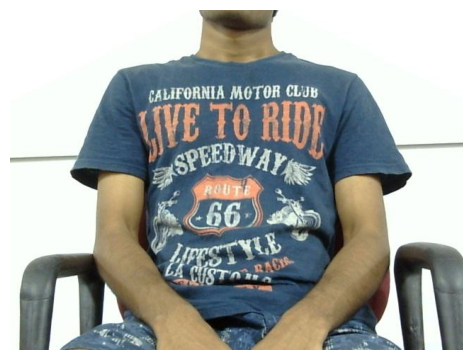

**__background__ | background | original**  
Status: `not_detected`, Haende: 0, Retry: True

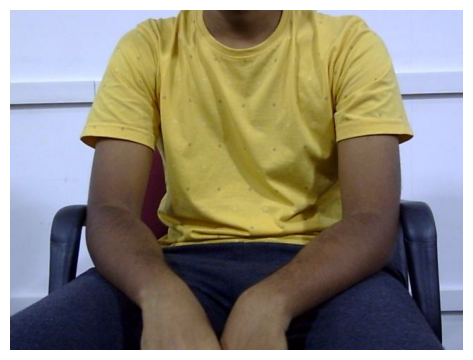

**ஔ | uyir | original**  
Status: `not_detected`, Haende: 0, Retry: True

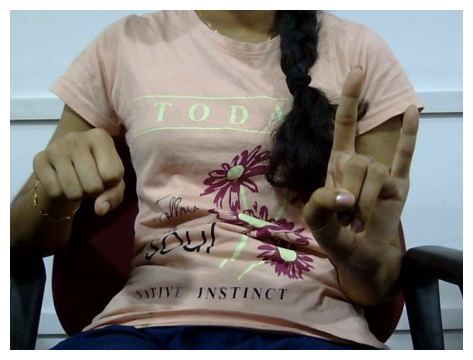

**நோ | uyirmei | original**  
Status: `incomplete_pair`, Haende: 1, Retry: True

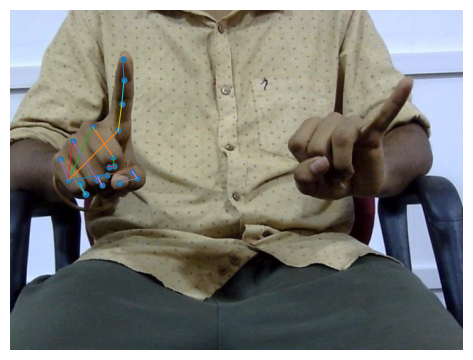

**இ | uyir | original**  
Status: `incomplete_pair`, Haende: 1, Retry: True

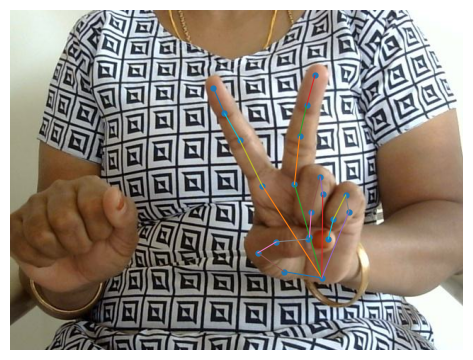

**ப் | mei | original**  
Status: `incomplete_pair`, Haende: 1, Retry: True

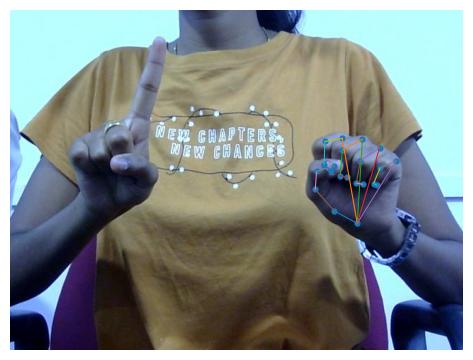

**வ் | mei** - Parameter: `{'angle': 3.752543923355016, 'brightness': 0.9411754711967887, 'contrast': 1.0053829915638937}`

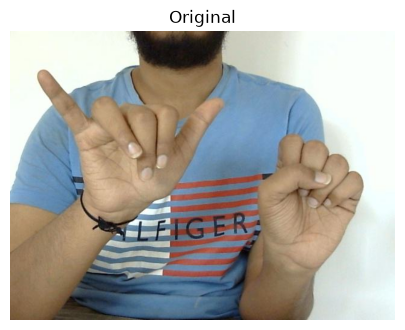

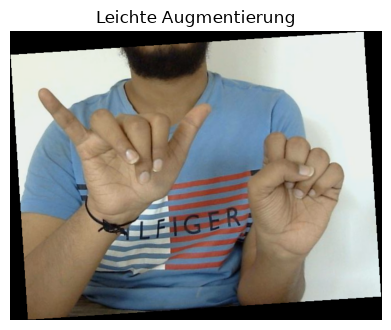

**இ | uyir** - Parameter: `{'angle': -4.81898249491855, 'brightness': 1.0820157759192033, 'contrast': 1.0584248081600443}`

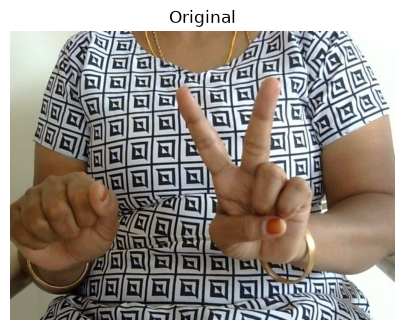

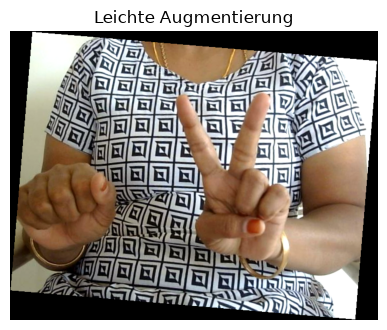

In [5]:
rows, directory = pilot_results[SELECTED_CONFIG]

review_cases = pd.concat([
    rows[rows["status"] == "ok"]
        .groupby("category", group_keys=False)
        .head(2),
    rows[rows["status"] != "ok"]
        .groupby("category", group_keys=False)
        .head(2),
]).drop_duplicates("sample_id")

print("Bilder zur visuellen Prüfung:", len(review_cases))

f.show_landmarks(
    PROJECT_ROOT,
    review_cases,
    directory,
    count=len(review_cases),
)

AUGMENT_TRAIN = True
augmentation_preview = (
    train.loc[train["category"].isin(["uyir", "mei"])]
    .sort_values("sha256")
    .groupby("category", sort=True)
    .head(1)
)

f.show_augmentation(
    PROJECT_ROOT,
    augmentation_preview,
    seed=42,
    count=2,
)


## 4. Feature-Konfiguration festschreiben

Die Konfiguration wird erst nach dem quantitativen Pilotvergleich und der visuellen Prüfung freigegeben. Die Entscheidung dokumentiert beobachtete Detektionsfehler, Background-Fälle und die Begründung für die Trainingsaugmentierung.


In [6]:
APPROVE_EXTRACTOR = True

FEATURE_NOTE = (
    "Im Pilot zeigte die Retry-Konfiguration die höchste Zwei-Hand-Erkennungsrate. "
    "Fehlende Detektionen traten insbesondere bei teilweise abgeschnittenen oder "
    "dunkleren Händen auf. Die zusätzlich erkannten Hände im Retry erschienen bei "
    "der visuellen Prüfung plausibel. Background-Bilder enthielten teilweise echte "
    "Hände ohne gültiges Zeichen und wurden daher nicht automatisch als "
    "Fehldetektionen gewertet. Die Landmarkpositionen erfolgreicher Fälle waren "
    "plausibel. Die leichte Augmentierung erhielt die erkennbare Zeichenstruktur."
)

if not APPROVE_EXTRACTOR:
    raise RuntimeError("Feature-Konfiguration ist nicht freigegeben.")

if not FEATURE_NOTE.strip():
    raise ValueError(
        "Für eine Freigabe muss FEATURE_NOTE die beobachteten Pilotbefunde dokumentieren."
    )

decision = f.save_feature_decision(
    PROJECT_ROOT,
    CONFIGS[SELECTED_CONFIG],
    APPROVE_EXTRACTOR,
    FEATURE_NOTE,
    augment_train=AUGMENT_TRAIN,
)

print("Feature-Konfiguration freigegeben:", SELECTED_CONFIG)


Feature-Konfiguration freigegeben: retry


## 5. Entwicklungsmerkmale extrahieren

Nach der Freigabe werden Merkmale für Training und Validation erzeugt. Nur Trainingsbilder erhalten die zusätzliche Augmentierungsvariante. Fehlende Merkmale werden als `NaN` gespeichert; der Testsplit bleibt vollständig ausgeschlossen. Bereits abgeschlossene Extraktionsblöcke können aus dem Cache wiederverwendet werden.


In [7]:
training_samples = f.samples(
    development,
    augment_train=AUGMENT_TRAIN,
    seed=42,
)

assert not training_samples["split"].eq("test").any(), (
    "Testdaten wurden unerwartet in die Feature-Extraktion aufgenommen."
)

assert (
    training_samples.loc[
        training_samples["split"].eq("validation"),
        "variant",
    ]
    .eq("original")
    .all()
), "Validation darf nicht augmentiert werden."

display(
    pd.crosstab(
        training_samples["split"],
        training_samples["variant"],
    )
)

feature_rows, feature_directory = f.run_extraction(
    PROJECT_ROOT,
    training_samples,
    CONFIGS[SELECTED_CONFIG],
    name="development",
    chunk_size=128,
    timeout=300,
)

f.save_development_pointer(
    PROJECT_ROOT,
    feature_directory,
)

display(
    f.detection_summary(feature_rows).round(3)
)


variant,mild_1,original
split,,
train,10800,50400
validation,0,12450


Cache: 128/73650
Cache: 256/73650
Cache: 384/73650
Cache: 512/73650
Cache: 640/73650
Cache: 768/73650
Cache: 896/73650
Cache: 1024/73650
Cache: 1152/73650
Cache: 1280/73650
Cache: 1408/73650
Cache: 1536/73650
Cache: 1664/73650
Cache: 1792/73650
Cache: 1920/73650
Cache: 2048/73650
Cache: 2176/73650
Cache: 2304/73650
Cache: 2432/73650
Cache: 2560/73650
Cache: 2688/73650
Cache: 2816/73650
Cache: 2944/73650
Cache: 3072/73650
Cache: 3200/73650
Cache: 3328/73650
Cache: 3456/73650
Cache: 3584/73650
Cache: 3712/73650
Cache: 3840/73650
Cache: 3968/73650
Cache: 4096/73650
Cache: 4224/73650
Cache: 4352/73650
Cache: 4480/73650
Cache: 4608/73650
Cache: 4736/73650
Cache: 4864/73650
Cache: 4992/73650
Cache: 5120/73650
Cache: 5248/73650
Cache: 5376/73650
Cache: 5504/73650
Cache: 5632/73650
Cache: 5760/73650
Cache: 5888/73650
Cache: 6016/73650
Cache: 6144/73650
Cache: 6272/73650
Cache: 6400/73650
Cache: 6528/73650
Cache: 6656/73650
Cache: 6784/73650
Cache: 6912/73650
Cache: 7040/73650
Cache: 7168/73650

,category,variant,n_images,n_two_hands,n_one_hand,n_no_hand,n_errors,median_ms,p95_ms,two_hand_rate
0,ayudha,original,410,236,95,79,0,32.772,52.041,0.576
1,background,original,460,71,23,366,0,26.596,49.262,0.154
2,mei,mild_1,6480,4716,946,818,0,36.960,56.313,0.728
3,mei,original,7380,5341,1086,953,0,32.293,50.610,0.724
4,uyir,mild_1,4320,2926,854,540,0,37.381,56.748,0.677
5,uyir,original,4920,3343,970,607,0,32.687,51.979,0.679
6,uyirmei,original,49680,37097,6745,5838,0,32.017,47.650,0.747


In [8]:
rows_check, X_check, meta_check = f.load_development(PROJECT_ROOT)

print("Feature-Matrix:", X_check.shape)

display(
    rows_check["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="n")
)

display(
    pd.crosstab(
        rows_check["split"],
        rows_check["variant"],
    )
)

print(
    "Testdaten enthalten:",
    rows_check["split"].eq("test").sum(),
)


Feature-Matrix: (73650, 178)


,status,n
0,ok,53730
1,incomplete_pair,10719
2,not_detected,9201


variant,mild_1,original
split,,
train,10800,50400
validation,0,12450


Testdaten enthalten: 0


## Ergebnis

Die Retry-Konfiguration erreichte im Pilot die höchste Zwei-Hand-Erkennungsrate für Zeichenbilder und wurde nach visueller Prüfung ausgewählt. Für Uyir und Mei wurde zusätzlich eine leichte Trainingsaugmentierung freigegeben.

Der Entwicklungsdatensatz enthält 73.650 Feature-Zeilen mit jeweils 178 Merkmalen. Davon konnten für 53.730 Bilder beide Hände vollständig erkannt werden; 10.719 Fälle enthielten nur eine erkannte Hand und bei 9.201 Bildern wurde keine Hand erkannt. Der Testsplit ist nicht Bestandteil der Feature-Extraktion.
